<a href="https://colab.research.google.com/github/alveslucas60-aluno/MN-Projetos/blob/main/Teste_dos_Splines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Spline Linear


Erro médio: 0.045707


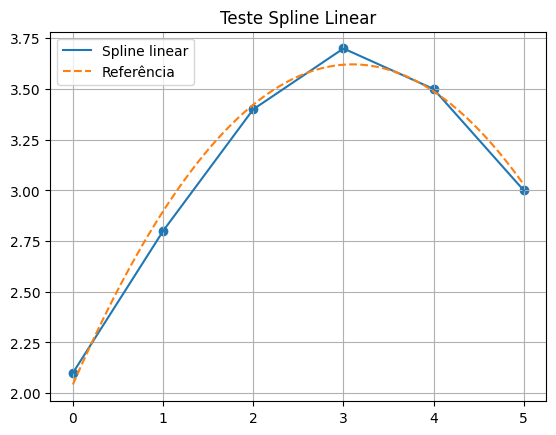

In [2]:
# ---------------------------------------------
# Este codigo realiza o teste de spline linear,
# apresentando o erro médio e o gráfico.
# ---------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# Dados

x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([2.1, 2.8, 3.4, 3.7, 3.5, 3.0]).astype(float)

# Função spline linear
def spline_linear(x, y, xp):
    for i in range(len(x)-1):
        if x[i] <= xp <= x[i+1]:
            return y[i] + (y[i+1]-y[i])*(xp-x[i])/(x[i+1]-x[i])

# Avaliação
x_plot = np.linspace(0,5,200)
y_plot = [spline_linear(x,y,xi) for xi in x_plot]

# Referencia / erro ( interpolação quadrática )
y_ref = np.polyval(np.polyfit(x,y,2), x_plot)
erro = np.abs(y_ref - y_plot)

# Resultados
print(f"Erro médio: {np.mean(erro):.6f}")

# Gráfico
plt.figure()
plt.plot(x_plot, y_plot, label='Spline linear')
plt.plot(x_plot, y_ref, '--', label='Referência')
plt.title('Teste Spline Linear')
plt.scatter(x,y)
plt.legend()
plt.grid(True)
plt.show()

##Spline Quadrática

Erro médio: 0.047283


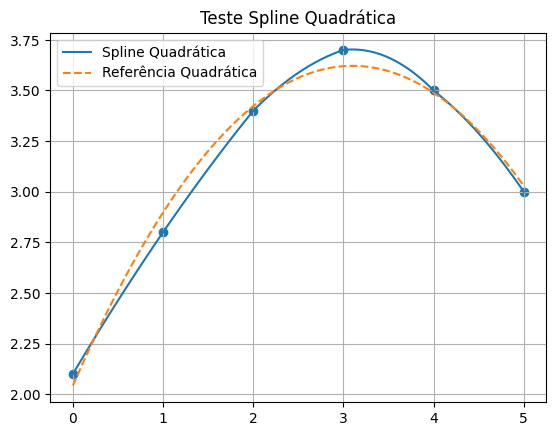

In [3]:
# ---------------------------------------------
# Este codigo realiza o teste de spline quadrática,
# apresentando o erro médio e o gráfico.
# ---------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# Dados
x = np.array([0, 1, 2, 3, 4, 5])

y = np.array([2.1, 2.8, 3.4, 3.7, 3.5, 3.0]).astype(float)

# Spline quadrática
def spline_quadratica(xp):

    for i in range(len(x)-2):

        if x[i] <= xp <= x[i+2]:

            # pontos locais
            x_local = x[i:i+3]
            y_local = y[i:i+3]
            # polinômio grau 2
            coef = np.polyfit(x_local,y_local,2)
            # valor interpolado
            return np.polyval(coef, xp)

# Avaliação
x_plot = np.linspace(0,5,200)

y_plot = np.array([
    spline_quadratica(xi)
    for xi in x_plot
    ])

# Referência / erro
y_ref = np.polyval(np.polyfit(x,y,2),x_plot)

erro = np.abs(y_ref - y_plot)

# Resultados
print(f"Erro médio: {np.mean(erro):.6f}")

# Gráfico
plt.figure()

plt.plot(x_plot,y_plot,label='Spline Quadrática')
plt.plot(x_plot,y_ref,'--',label='Referência Quadrática')
plt.title('Teste Spline Quadrática')
plt.scatter(x,y)
plt.legend()
plt.grid(True)
plt.show()

##Spline Cubica


Erro médio: 0.030439


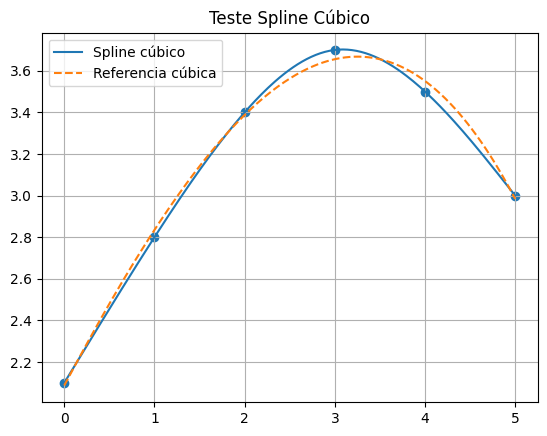

In [4]:
# ---------------------------------------------
# Este codigo realiza o teste de spline cúbica,
# apresentando o erro médio e o gráfico.
# ---------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Dados
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([2.1, 2.8, 3.4, 3.7, 3.5, 3.0]).astype(float)

# Spline cúbico natural
cs = CubicSpline(x,y, bc_type='natural')

x_plot = np.linspace(0,5,200)
y_plot = cs(x_plot)

# referência (polinômio grau 3)
y_ref = np.polyval(np.polyfit(x,y,3), x_plot)
erro = np.abs(y_ref - y_plot)

# Resultados
print(f"Erro médio: {np.mean(erro):.6f}")

# Gráfico
plt.figure()
plt.plot(x_plot, y_plot, label='Spline cúbico')
plt.plot(x_plot, y_ref, '--', label='Referencia cúbica')
plt.title('Teste Spline Cúbico')
plt.scatter(x,y)
plt.legend()
plt.grid(True)
plt.show()